# Prediction Nutri-Score — Version Optimisee

Ameliorations par rapport aux notebooks precedents :

| # | Levier | Detail |
|---|---|---|
| 1 | **Features etendues** | `nova_group`, `additives_n`, ratios derives |
| 2 | **IterativeImputer (ExtraTrees)** | Imputation iterative robuste |
| 3 | **LightGBM** | Classifieur gradient boosting rapide et precis |
| 4 | **Class weight** | Equilibrage automatique des grades |
| 5 | **RandomizedSearchCV** | Optimisation des hyperparametres |
| 6 | **Scoring complet** | Rapport, F1 par grade, matrices de confusion |

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)
from sklearn.pipeline import Pipeline

try:
    from lightgbm import LGBMClassifier
    LGBM_OK = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    LGBM_OK = False
    print("LightGBM non installe, on utilise GradientBoostingClassifier a la place.")
    print("Pour installer : pip install lightgbm")

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
print(f"LightGBM disponible : {LGBM_OK}")

LightGBM disponible : True


## 1. Chargement des datasets

In [3]:
TARGET = 'nutriscore_grade'
GRADES_VALIDES = ['a', 'b', 'c', 'd', 'e']

def charger(path):
    import os
    for p in [path, '../' + path, 'Nutri/' + path]:
        if os.path.exists(p):
            return pd.read_csv(p, low_memory=False)
    raise FileNotFoundError(f"Introuvable : {path}")

df_train = charger('traité_avec_nutriscore.csv')
df_train[TARGET] = df_train[TARGET].str.lower().str.strip()
df_train = df_train[df_train[TARGET].isin(GRADES_VALIDES)]

df_pred = charger('traité_sans_nutriscore.csv')

print(f"Entrainement  : {len(df_train):,} produits")
print(f"A predire     : {len(df_pred):,} produits")
print(f"\nDistribution des grades :")
print(df_train[TARGET].value_counts().sort_index())

Entrainement  : 58,903 produits
A predire     : 32,394 produits

Distribution des grades :
nutriscore_grade
a    11846
b    11722
c    11803
d    11800
e    11732
Name: count, dtype: int64


## 2. Feature Engineering

On etend les features de base (7 nutriments) avec :
- `nova_group` et `additives_n` : tres correles au Nutri-Score  
- Ratios derives : `sugars_ratio`, `sat_fat_ratio`

In [4]:
BASE_FEATURES = [
    'energy_100g',
    'sugars_100g',
    'saturated-fat_100g',
    'salt_100g',
    'fiber_100g',
    'proteins_100g',
    'fruits-vegetables-legumes_100g',
]

def feature_engineering(df):
    df = df.copy()
    # Converti les colonnes numeriques
    for col in BASE_FEATURES + ['nova_group', 'additives_n', 'carbohydrates_100g', 'fat_100g']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Ratios derives (eviter division par zero)
    if 'sugars_100g' in df.columns and 'carbohydrates_100g' in df.columns:
        df['sugars_ratio'] = df['sugars_100g'] / (df['carbohydrates_100g'] + 1e-6)
    if 'saturated-fat_100g' in df.columns and 'fat_100g' in df.columns:
        df['sat_fat_ratio'] = df['saturated-fat_100g'] / (df['fat_100g'] + 1e-6)

    return df

df_train = feature_engineering(df_train)
df_pred  = feature_engineering(df_pred)

# Features finales
EXTRA_FEATURES = ['nova_group', 'additives_n', 'sugars_ratio', 'sat_fat_ratio']
ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES

features_dispo = [f for f in ALL_FEATURES if f in df_train.columns]
print(f"Features utilisees ({len(features_dispo)}) :")
for f in features_dispo:
    n_null = df_train[f].isna().sum()
    pct = 100 * n_null / len(df_train)
    print(f"  {f:<40} {n_null:>7,} NaN ({pct:5.1f}%)")

Features utilisees (10) :
  sugars_100g                                    0 NaN (  0.0%)
  saturated-fat_100g                             0 NaN (  0.0%)
  salt_100g                                      0 NaN (  0.0%)
  fiber_100g                                     0 NaN (  0.0%)
  proteins_100g                                  0 NaN (  0.0%)
  fruits-vegetables-legumes_100g                 0 NaN (  0.0%)
  nova_group                                 2,637 NaN (  4.5%)
  additives_n                                    0 NaN (  0.0%)
  sugars_ratio                                   0 NaN (  0.0%)
  sat_fat_ratio                                  0 NaN (  0.0%)


In [5]:
X = df_train[features_dispo]
y = df_train[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {len(X_train):,}  |  Test (hold-out 20%) : {len(X_test):,}")

Train : 47,122  |  Test (hold-out 20%) : 11,781


## 3. Pipeline : IterativeImputer + LightGBM

- **Imputation** : `IterativeImputer` avec `ExtraTreesRegressor`  
- **Classifieur** : `LGBMClassifier` (ou `GradientBoostingClassifier` si LightGBM absent)  
- **class_weight='balanced'** : compense le desequilibre entre grades

In [6]:
imputer = IterativeImputer(
    estimator=ExtraTreesRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    max_iter=10,
    random_state=42,
    verbose=0
)

if LGBM_OK:
    clf = LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=7,
        num_leaves=63,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
else:
    from sklearn.ensemble import GradientBoostingClassifier
    clf = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    )

pipeline = Pipeline([
    ('imputer', imputer),
    ('clf', clf)
])

clf_name = 'LGBMClassifier' if LGBM_OK else 'GradientBoostingClassifier'
print(f"Pipeline pret : IterativeImputer -> {clf_name}")

Pipeline pret : IterativeImputer -> LGBMClassifier


## 4. Cross-Validation Stratifiee (k=5)

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    pipeline, X_train, y_train,
    cv=cv,
    scoring=['accuracy', 'f1_macro'],
    return_train_score=True,
    n_jobs=-1
)

df_cv = pd.DataFrame({
    'Fold'           : range(1, 6),
    'Train Accuracy' : cv_results['train_accuracy'].round(4),
    'Val Accuracy'   : cv_results['test_accuracy'].round(4),
    'Val F1-macro'   : cv_results['test_f1_macro'].round(4),
})
print(df_cv.to_string(index=False))
print(f"\nMoyenne Val Accuracy : {df_cv['Val Accuracy'].mean():.4f} +/- {df_cv['Val Accuracy'].std():.4f}")
print(f"Moyenne Val F1-macro : {df_cv['Val F1-macro'].mean():.4f} +/- {df_cv['Val F1-macro'].std():.4f}")

 Fold  Train Accuracy  Val Accuracy  Val F1-macro
    1          0.9738        0.9101        0.9103
    2          0.9751        0.9006        0.9008
    3          0.9753        0.9065        0.9068
    4          0.9747        0.9072        0.9075
    5          0.9752        0.9022        0.9025

Moyenne Val Accuracy : 0.9053 +/- 0.0039
Moyenne Val F1-macro : 0.9056 +/- 0.0039


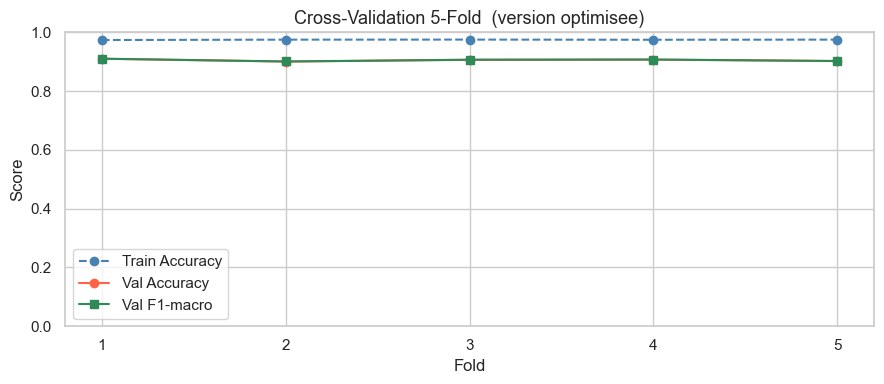

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(1, 6)
ax.plot(x, cv_results['train_accuracy'], 'o--', label='Train Accuracy', color='steelblue')
ax.plot(x, cv_results['test_accuracy'],  'o-',  label='Val Accuracy',   color='tomato')
ax.plot(x, cv_results['test_f1_macro'],  's-',  label='Val F1-macro',   color='seagreen')
ax.set_xticks(list(x))
ax.set_xlabel('Fold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Cross-Validation 5-Fold  (version optimisee)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Optimisation des hyperparametres (RandomizedSearchCV)

On cherche les meilleurs parametres du classifieur via 15 iterations aleatoires.  
**Note** : cette cellule peut prendre plusieurs minutes.

In [9]:
if LGBM_OK:
    param_dist = {
        'clf__n_estimators'   : [200, 300, 500],
        'clf__learning_rate'  : [0.03, 0.05, 0.1, 0.15],
        'clf__max_depth'      : [5, 7, 10, -1],
        'clf__num_leaves'     : [31, 63, 127],
        'clf__min_child_samples': [10, 20, 50],
        'clf__subsample'      : [0.7, 0.8, 1.0],
        'clf__colsample_bytree': [0.7, 0.8, 1.0],
    }
else:
    param_dist = {
        'clf__n_estimators'  : [200, 300, 500],
        'clf__learning_rate' : [0.03, 0.05, 0.1],
        'clf__max_depth'     : [3, 5, 7],
        'clf__min_samples_leaf': [5, 10, 20],
    }

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=15,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
search.fit(X_train, y_train)

print(f"\nMeilleur F1-macro CV : {search.best_score_:.4f}")
print("Meilleurs parametres :")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

best_pipeline = search.best_estimator_

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Meilleur F1-macro CV : 0.9067
Meilleurs parametres :
  clf__subsample: 0.8
  clf__num_leaves: 31
  clf__n_estimators: 500
  clf__min_child_samples: 20
  clf__max_depth: 10
  clf__learning_rate: 0.15
  clf__colsample_bytree: 1.0


## 6. Evaluation finale sur le Hold-out (20%)



In [10]:
y_pred = best_pipeline.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred, average='macro')

print(f"Hold-out Accuracy  : {acc:.4f}")
print(f"Hold-out F1-macro  : {f1:.4f}")
print()
print(classification_report(y_test, y_pred, digits=4))

C:\Users\Gambey\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Hold-out Accuracy  : 0.9187
Hold-out F1-macro  : 0.9188

              precision    recall  f1-score   support

           a     0.9332    0.9312    0.9322      2369
           b     0.8682    0.9019    0.8847      2344
           c     0.9099    0.8810    0.8952      2361
           d     0.9229    0.9280    0.9254      2360
           e     0.9613    0.9514    0.9563      2347

    accuracy                         0.9187     11781
   macro avg     0.9191    0.9187    0.9188     11781
weighted avg     0.9191    0.9187    0.9188     11781



In [11]:
report = classification_report(y_test, y_pred, digits=4, output_dict=True)
df_report = pd.DataFrame(report).T
df_report['support'] = df_report['support'].astype(int)

display(df_report.style
    .format({'precision': '{:.4f}', 'recall': '{:.4f}', 'f1-score': '{:.4f}', 'support': '{:,d}'})
    .background_gradient(subset=['precision', 'recall', 'f1-score'], cmap='RdYlGn', vmin=0, vmax=1)
    .set_caption(f"Hold-out Accuracy : {acc:.4f}  |  F1-macro : {f1:.4f}")
)

,precision,recall,f1-score,support
a,0.9332,0.9312,0.9322,"2,369"
b,0.8682,0.9019,0.8847,"2,344"
c,0.9099,0.8810,0.8952,"2,361"
d,0.9229,0.9280,0.9254,"2,360"
e,0.9613,0.9514,0.9563,"2,347"
accuracy,0.9187,0.9187,0.9187,0
macro avg,0.9191,0.9187,0.9188,"11,781"
weighted avg,0.9191,0.9187,0.9188,"11,781"


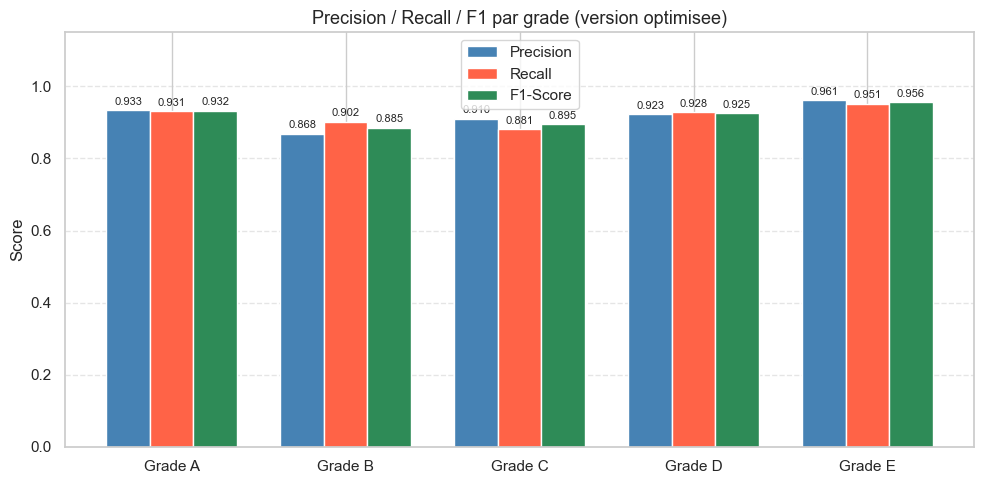

In [ ]:
grades = ['a', 'b', 'c', 'd', 'e']
precisions = [report[g]['precision'] for g in grades]
recalls    = [report[g]['recall']    for g in grades]
f1s        = [report[g]['f1-score']  for g in grades]

x = np.arange(len(grades))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w, precisions, w, label='Precision', color='steelblue')
bars2 = ax.bar(x,     recalls,    w, label='Recall',    color='tomato')
bars3 = ax.bar(x + w, f1s,        w, label='F1-Score',  color='seagreen')
for bar in list(bars1) + list(bars2) + list(bars3):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels([f'Grade {g.upper()}' for g in grades], fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 par grade (version optimisee)', fontsize=13)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

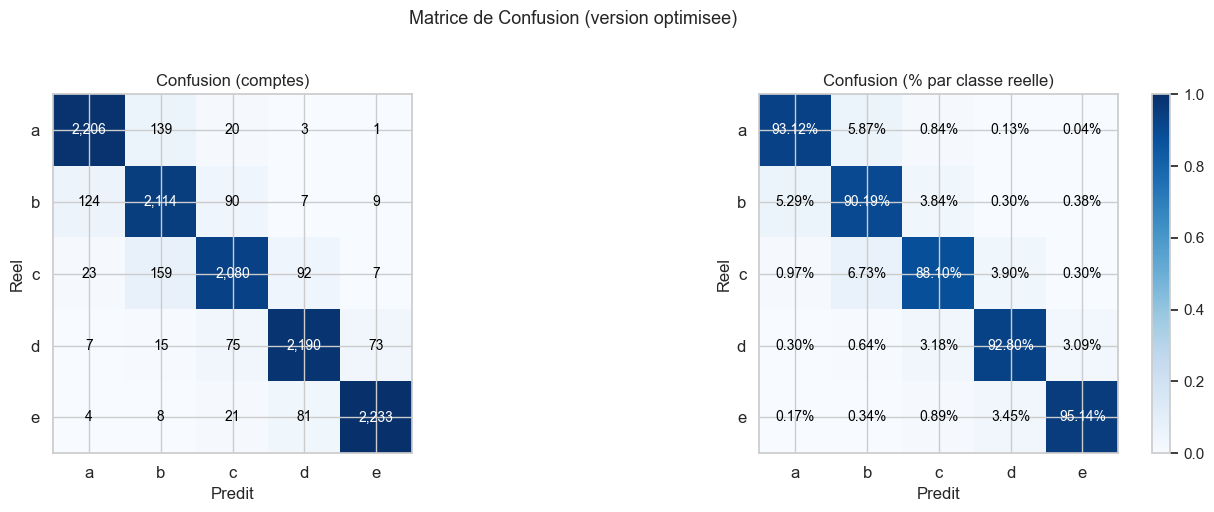

In [13]:
labels  = ['a', 'b', 'c', 'd', 'e']
cm      = confusion_matrix(y_test, y_pred, labels=labels)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks(range(len(labels)))
axes[0].set_yticks(range(len(labels)))
axes[0].set_xticklabels(labels, fontsize=12)
axes[0].set_yticklabels(labels, fontsize=12)
axes[0].set_xlabel('Predit', fontsize=12)
axes[0].set_ylabel('Reel',   fontsize=12)
axes[0].set_title('Confusion (comptes)', fontsize=12)
for i in range(len(labels)):
    for j in range(len(labels)):
        axes[0].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     color='white' if cm[i,j] > cm.max()*0.6 else 'black', fontsize=10)

im1 = axes[1].imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
axes[1].set_xticks(range(len(labels)))
axes[1].set_yticks(range(len(labels)))
axes[1].set_xticklabels(labels, fontsize=12)
axes[1].set_yticklabels(labels, fontsize=12)
axes[1].set_xlabel('Predit', fontsize=12)
axes[1].set_ylabel('Reel',   fontsize=12)
axes[1].set_title('Confusion (% par classe reelle)', fontsize=12)
for i in range(len(labels)):
    for j in range(len(labels)):
        axes[1].text(j, i, f'{cm_norm[i,j]:.2%}', ha='center', va='center',
                     color='white' if cm_norm[i,j] > 0.6 else 'black', fontsize=10)
plt.colorbar(im1, ax=axes[1])
plt.suptitle('Matrice de Confusion (version optimisee)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Importance des features

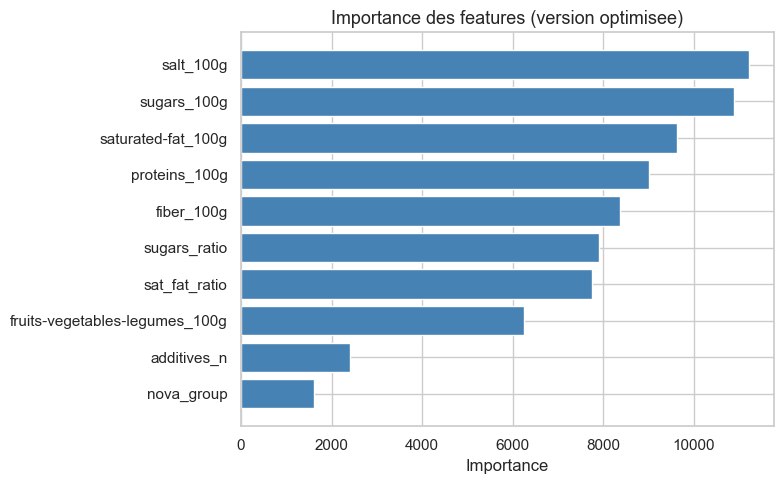

In [14]:
try:
    clf_step = best_pipeline.named_steps['clf']
    importances = clf_step.feature_importances_
    df_imp = pd.DataFrame({'feature': features_dispo, 'importance': importances})
    df_imp = df_imp.sort_values('importance', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(df_imp['feature'], df_imp['importance'], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title('Importance des features (version optimisee)', fontsize=13)
    plt.tight_layout()
    plt.show()
except AttributeError:
    print("Ce classifieur ne fournit pas feature_importances_.")

## 8. Prediction sur les produits sans Nutri-Score

In [15]:
features_pred = [f for f in features_dispo if f in df_pred.columns]
X_pred = df_pred[features_pred]

pred_grades = best_pipeline.predict(X_pred)
df_pred_out = df_pred.copy()
df_pred_out['nutriscore_grade_predit'] = pred_grades

print(f"Produits predits : {len(df_pred_out):,}")
print("\nDistribution des grades predits :")
print(df_pred_out['nutriscore_grade_predit'].value_counts().sort_index())

# output_path = 'predictions_sans_nutriscore_optimise.csv'
# df_pred_out.to_csv(output_path, index=False, encoding='utf-8-sig')
# print(f"\nFichier sauvegarde : {output_path}")

C:\Users\Gambey\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Produits predits : 32,394

Distribution des grades predits :
nutriscore_grade_predit
a    4219
b    5457
c    5987
d    7074
e    9657
Name: count, dtype: int64
